In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

from datetime import datetime

In [4]:
ticker = "AAPL"

start_date = "2015-01-01"

end_date = datetime.today().strftime("%Y-%m-%d")

In [5]:
prices = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

prices.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842976,23.942551,23.610630,23.721271,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


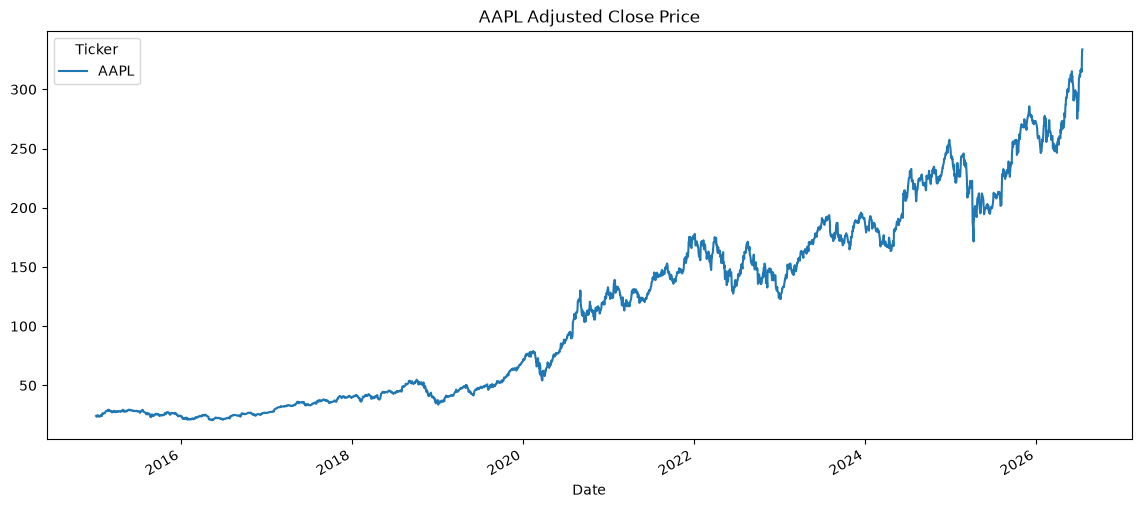

In [6]:
close = prices["Close"]

close.plot(
    figsize=(14,6),
    title=f"{ticker} Adjusted Close Price"
)

plt.show()

In [7]:
returns = close.pct_change().dropna()

returns.head()

Ticker,AAPL
Date,
2015-01-05,-0.028172
2015-01-06,0.000094
2015-01-07,0.014022
2015-01-08,0.038423
2015-01-09,0.001072


In [8]:
log_returns = np.log(
    close / close.shift(1)
).dropna()

log_returns.head()

Ticker,AAPL
Date,
2015-01-05,-0.028576
2015-01-06,0.000094
2015-01-07,0.013925
2015-01-08,0.037703
2015-01-09,0.001072


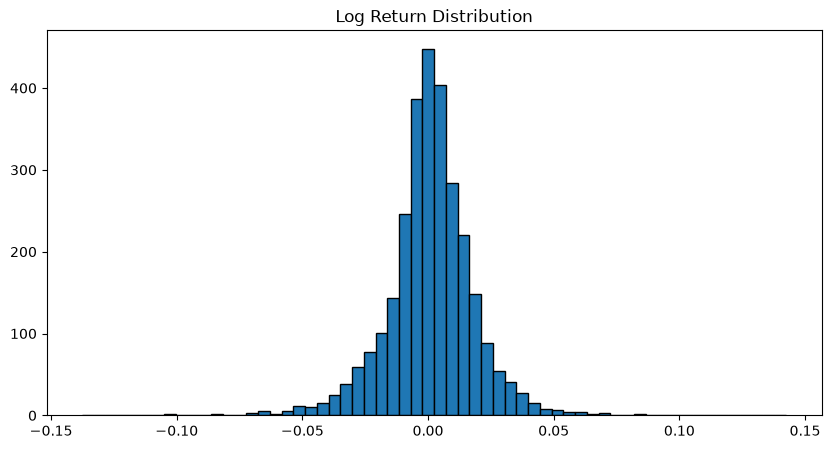

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    log_returns,
    bins=60,
    edgecolor="black"
)

plt.title("Log Return Distribution")

plt.show()

In [10]:
rolling_mean = log_returns.rolling(20).mean()

In [11]:
rolling_vol = log_returns.rolling(20).std()

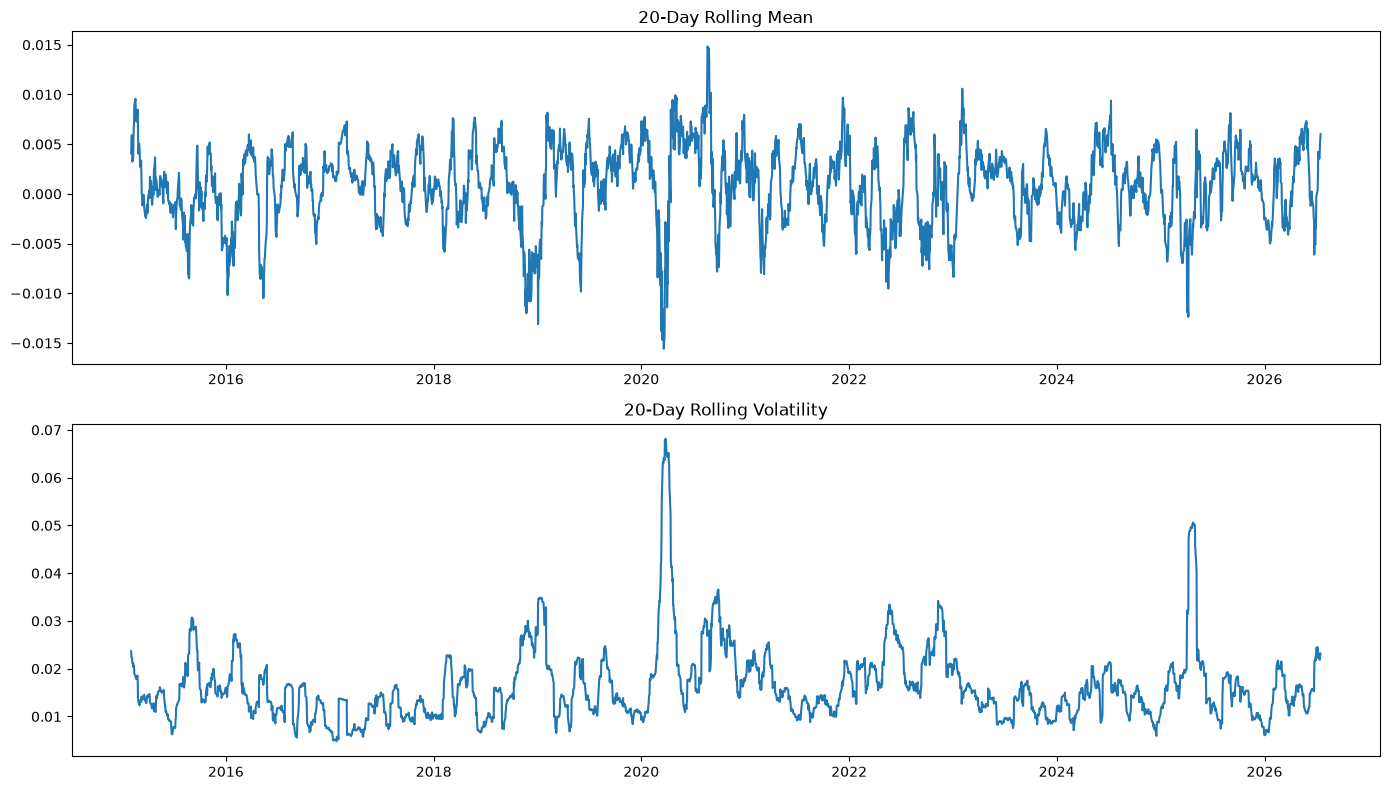

In [12]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(14,8)
)

ax[0].plot(
    rolling_mean
)

ax[0].set_title(
    "20-Day Rolling Mean"
)

ax[1].plot(
    rolling_vol
)

ax[1].set_title(
    "20-Day Rolling Volatility"
)

plt.tight_layout()

plt.show()

In [13]:
prices.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [14]:
print("Observations:", len(prices))

print("Returns:", len(log_returns))

Observations: 2901
Returns: 2900
